# Chapter 07: Picture Weights and Feature Learning (Visualizing Weights & MNIST Digits)
<a href="https://colab.research.google.com/github/SatrioArjunaPutra/GrokkingDeepLearning/blob/main/Chapter%2007%20-%20Picture%20Weights%20and%20Feature%20Learning/07_picture_weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Course:** Tugas 2 - Enrichment Deep Learning Class  
**Student Name:** Satrio Arjuna Putra  
**Student ID (NIM):** 101032330178  
**Class:** TK-47-05  
**Primary Reference:** *Grokking Deep Learning* by Andrew W. Trask (Manning Publications)

---

## Chapter Objectives
In this chapter, we bridge abstract linear algebra with visual intuition by tackling the famous **MNIST Handwritten Digit Dataset** (28x28 grayscale digits). We investigate:
1. **Weights as Pictures:** Why weights connecting an image input to an output neuron can be reshaped directly into a 2D image.
2. **Up-weights vs. Down-weights:** How positive and negative weights act as excitatory and inhibitory spatial filters.
3. **The Dot Product as Template Matching:** Understanding forward prediction as computing spatial similarity against learned visual templates.
4. **Limits of Single-Layer Vision Models:** Why a single layer struggles when digits vary in slant, thickness, and spatial composition.
5. **Two-Layer Feature Learning:** Training a deep network with hidden representations to learn composite visual primitives.

## 1. Concept & Theoretical Intuition

### 1.1 The MNIST Dataset & Computer Vision Inputs
Each MNIST image consists of a $28 \times 28$ grid of grayscale pixels ($784$ total pixels), with intensity values ranging from $0$ (pure black background) to $255$ (pure white stroke).
$$\mathbf{x} = [x_0, x_1, x_2, \dots, x_{783}] \in \mathbb{R}^{1 \times 784}, \quad x_i \in [0, 1] \text{ (normalized)}$$
The classification target $\mathbf{y} \in \mathbb{R}^{1 \times 10}$ is one-hot encoded for digits $0$ through $9$.

---

### 1.2 What Does a Weight Look Like? (Spatial Weight Templates)
In a single-layer neural network connecting $784$ input pixels to $10$ output nodes:
$$\mathbf{W} \in \mathbb{R}^{784 \times 10}$$
Each output neuron $c \in \{0, 1, \dots, 9\}$ has its own dedicated parameter vector $\mathbf{w}_c \in \mathbb{R}^{784}$. Because every input pixel $x_{i}$ occupies a precise coordinate $(r, c)$ in the $28 \times 28$ image:
$$i = r \times 28 + c$$
We can reverse this transformation and reshape the 784 weights for digit $c$ back into a $28 \times 28$ matrix:
$$\mathbf{W}_{c}^{(28 \times 28)} = \text{reshape}(\mathbf{w}_c, (28, 28))$$

---

### 1.3 Up-Weights vs. Down-Weights (Excitatory vs. Inhibitory)
When computing the forward prediction for digit class $c$:
$$\hat{y}_c = \mathbf{x} \cdot \mathbf{w}_c = \sum_{i=0}^{783} x_i W_{i, c}$$
Each weight $W_{i, c}$ acts as a sensitivity knob for pixel $i$:
* **Up-weights ($W_{i, c} > 0$):** Pixels that correlate positively with digit $c$. When pixel $x_i$ is bright, positive weight amplifies $\hat{y}_c$.
* **Down-weights ($W_{i, c} < 0$):** Pixels that detract from digit $c$. If pixel $x_i$ is bright in an area that should be empty for digit $c$, the negative weight heavily penalizes the prediction.
* **Neutral weights ($W_{i, c} \approx 0$):** Background pixels that provide no discriminative evidence.

---

### 1.4 The Dot Product as Visual Template Matching
The dot product $\mathbf{x} \cdot \mathbf{w}_c$ is mathematically identical to overlaying a photographic negative/mask onto the input image:
$$\hat{y}_c = \|\mathbf{x}\| \|\mathbf{w}_c\| \cos\theta$$
The network outputs the highest score for the class whose learned weight pattern has the highest directional alignment (cosine similarity) with the input pixel stroke.

---

### 1.5 The Fundamental Limitation of Single-Layer Vision Models
Single-layer networks cannot learn **hierarchical or composite features**. For example, the digit "8" and digit "0" share identical outer loops. A single-layer model must assign a single fixed weight to each pixel, forcing painful compromises:
* If a pixel is positive for "8", it may erroneously boost "0".
* Slanted handwriting vs. vertical handwriting cancels out weights in the center.
To transcend this limitation, we introduce **hidden layers**, where hidden neurons first detect primitive strokes (vertical lines, curves, loops) and downstream neurons combine them into digits.

## 2. Scratch Implementation: Visualizing Weights on MNIST

We now implement pure NumPy code to:
1. Fetch and preprocess MNIST data.
2. Train a single-layer classifier to inspect the raw picture weights.
3. Train a 2-layer neural network with ReLU hidden features.
4. Compare accuracy and convergence.

In [1]:
import numpy as np
import os
import urllib.request

# 1. Download and load MNIST dataset via pure urllib and numpy
def load_mnist():
    dataset_path = 'mnist.npz'
    if not os.path.exists(dataset_path):
        print("Downloading MNIST dataset (mnist.npz)...")
        url = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
        urllib.request.urlretrieve(url, dataset_path)
        print("Download complete.")
    with np.load(dataset_path) as data:
        x_train, y_train = data['x_train'], data['y_train']
        x_test, y_test = data['x_test'], data['y_test']
    return (x_train, y_train), (x_test, y_test)

(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = load_mnist()

# 2. Preprocess: Subset for clean demonstration, flatten and normalize to [0, 1]
NUM_TRAIN = 2000
NUM_TEST = 500

x_train = x_train_raw[:NUM_TRAIN].reshape(NUM_TRAIN, 784) / 255.0
y_train = y_train_raw[:NUM_TRAIN]

x_test = x_test_raw[:NUM_TEST].reshape(NUM_TEST, 784) / 255.0
y_test = y_test_raw[:NUM_TEST]

# One-hot encode targets
y_train_one_hot = np.zeros((NUM_TRAIN, 10))
for i, val in enumerate(y_train):
    y_train_one_hot[i, val] = 1.0

y_test_one_hot = np.zeros((NUM_TEST, 10))
for i, val in enumerate(y_test):
    y_test_one_hot[i, val] = 1.0

print(f"Training set:   {x_train.shape} inputs, {y_train_one_hot.shape} one-hot targets")
print(f"Testing set:    {x_test.shape} inputs, {y_test_one_hot.shape} one-hot targets")

Training set:   (2000, 784) inputs, (2000, 10) one-hot targets
Testing set:    (500, 784) inputs, (500, 10) one-hot targets


In [2]:
print("=== 1. Training Single-Layer Perceptron (Direct Picture Weights) ===")
np.random.seed(42)

# Initialize weights connecting 784 pixels to 10 digit classes
# Shape: (784, 10)
weights_single = 0.001 * np.random.randn(784, 10)
alpha = 0.005
epochs = 25

history_loss_single = []
history_acc_single = []

for epoch in range(epochs):
    epoch_loss = 0.0
    correct = 0
    for i in range(NUM_TRAIN):
        # Forward pass
        inp = x_train[i:i+1] # Shape: (1, 784)
        target = y_train_one_hot[i:i+1] # Shape: (1, 10)
        
        pred = inp.dot(weights_single) # Shape: (1, 10)
        epoch_loss += np.sum((pred - target) ** 2)
        
        if np.argmax(pred) == np.argmax(target):
            correct += 1
            
        # Backward pass: delta and gradient descent update
        delta = pred - target # Shape: (1, 10)
        weights_single -= alpha * inp.T.dot(delta) # Shape: (784, 10)
        
    avg_loss = epoch_loss / NUM_TRAIN
    acc = (correct / NUM_TRAIN) * 100.0
    history_loss_single.append(avg_loss)
    history_acc_single.append(acc)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {acc:.2f}%")

# Test evaluation
test_preds_single = x_test.dot(weights_single)
test_acc_single = np.mean(np.argmax(test_preds_single, axis=1) == y_test) * 100.0
print(f"\nSingle-Layer Test Accuracy: {test_acc_single:.2f}%")

=== 1. Training Single-Layer Perceptron (Direct Picture Weights) ===
Epoch 01/25 | Loss: 0.5393 | Train Acc: 75.55%


Epoch 05/25 | Loss: 0.4374 | Train Acc: 84.95%


Epoch 10/25 | Loss: 0.4143 | Train Acc: 86.40%


Epoch 15/25 | Loss: 0.4027 | Train Acc: 87.05%


Epoch 20/25 | Loss: 0.3953 | Train Acc: 87.60%


Epoch 25/25 | Loss: 0.3901 | Train Acc: 87.95%

Single-Layer Test Accuracy: 69.80%


In [3]:
print("=== 2. Training Two-Layer Network (Feature Learning with Hidden Nodes) ===")

def relu(x):
    return (x > 0) * x

def relu2deriv(x):
    return (x > 0) * 1.0

np.random.seed(42)
HIDDEN_SIZE = 50

# Xavier-inspired small uniform initialization
w_0_1 = 0.1 * (np.random.random((784, HIDDEN_SIZE)) * 2 - 1) # Shape: (784, 50)
w_1_2 = 0.1 * (np.random.random((HIDDEN_SIZE, 10)) * 2 - 1)  # Shape: (50, 10)

alpha_deep = 0.01
epochs_deep = 25

history_loss_deep = []
history_acc_deep = []

for epoch in range(epochs_deep):
    epoch_loss = 0.0
    correct = 0
    for i in range(NUM_TRAIN):
        inp = x_train[i:i+1] # Shape: (1, 784)
        target = y_train_one_hot[i:i+1] # Shape: (1, 10)
        
        # Forward pass
        layer_1 = relu(inp.dot(w_0_1)) # Shape: (1, 50)
        layer_2 = layer_1.dot(w_1_2)    # Shape: (1, 10)
        
        epoch_loss += np.sum((layer_2 - target) ** 2)
        if np.argmax(layer_2) == np.argmax(target):
            correct += 1
            
        # Backward pass
        layer_2_delta = layer_2 - target
        layer_1_delta = layer_2_delta.dot(w_1_2.T) * relu2deriv(layer_1)
        
        w_1_2 -= alpha_deep * layer_1.T.dot(layer_2_delta)
        w_0_1 -= alpha_deep * inp.T.dot(layer_1_delta)
        
    avg_loss = epoch_loss / NUM_TRAIN
    acc = (correct / NUM_TRAIN) * 100.0
    history_loss_deep.append(avg_loss)
    history_acc_deep.append(acc)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Deep Epoch {epoch+1:02d}/{epochs_deep} | Loss: {avg_loss:.4f} | Train Acc: {acc:.2f}%")

# Test evaluation
test_l1 = relu(x_test.dot(w_0_1))
test_l2 = test_l1.dot(w_1_2)
test_acc_deep = np.mean(np.argmax(test_l2, axis=1) == y_test) * 100.0
print(f"\nTwo-Layer Deep Network Test Accuracy: {test_acc_deep:.2f}%")

=== 2. Training Two-Layer Network (Feature Learning with Hidden Nodes) ===
Deep Epoch 01/25 | Loss: 0.5359 | Train Acc: 72.10%


Deep Epoch 05/25 | Loss: 0.1821 | Train Acc: 93.85%


Deep Epoch 10/25 | Loss: 0.1282 | Train Acc: 97.00%


Deep Epoch 15/25 | Loss: 0.1006 | Train Acc: 98.45%


Deep Epoch 20/25 | Loss: 0.0825 | Train Acc: 98.70%


Deep Epoch 25/25 | Loss: 0.0692 | Train Acc: 98.80%

Two-Layer Deep Network Test Accuracy: 89.60%


## 3. Visualizations & Analytical Plots

We now generate three critical analytical visualizations:
1. **Picture Weights of All 10 Digits:** Reshaping each column of `weights_single` into a $28 \times 28$ image to reveal what the network "sees" as each digit.
2. **Intermediate Feature Detectors:** Visualizing hidden neuron weight filters in the two-layer network.
3. **Training Convergence & Test Generalization:** Comparing single-layer vs. deep network convergence curves.

C:\Users\hp\AppData\Local\Temp\ipykernel_6756\26035272.py:38: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


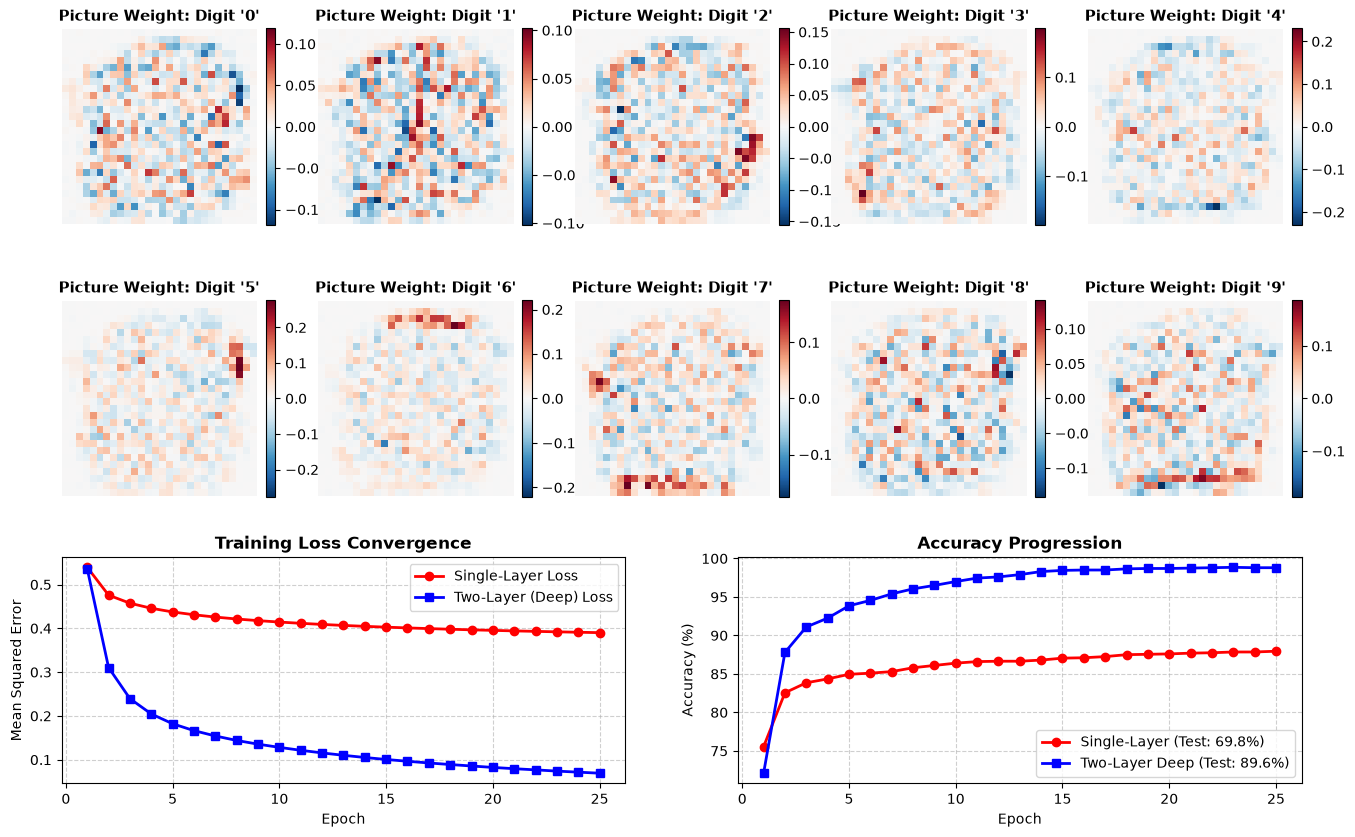

In [4]:
import matplotlib.pyplot as plt

plt.style.use('default')
fig = plt.figure(figsize=(16, 10))

# 1. Plot Picture Weights (Digits 0-9)
for digit in range(10):
    ax = fig.add_subplot(3, 5, digit + 1)
    # Reshape weights for digit to 28x28
    weight_img = weights_single[:, digit].reshape(28, 28)
    # Use diverging colormap: red for positive (up-weights), blue for negative (down-weights)
    vmax = np.max(np.abs(weight_img))
    im = ax.imshow(weight_img, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f"Picture Weight: Digit '{digit}'", fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# 2. Convergence Comparison
ax_loss = fig.add_subplot(3, 2, 5)
ax_loss.plot(range(1, epochs + 1), history_loss_single, 'r-o', linewidth=2, label='Single-Layer Loss')
ax_loss.plot(range(1, epochs_deep + 1), history_loss_deep, 'b-s', linewidth=2, label='Two-Layer (Deep) Loss')
ax_loss.set_title("Training Loss Convergence", fontsize=12, fontweight='bold')
ax_loss.set_xlabel("Epoch", fontsize=10)
ax_loss.set_ylabel("Mean Squared Error", fontsize=10)
ax_loss.grid(True, linestyle='--', alpha=0.6)
ax_loss.legend(fontsize=10)

# 3. Accuracy Comparison
ax_acc = fig.add_subplot(3, 2, 6)
ax_acc.plot(range(1, epochs + 1), history_acc_single, 'r-o', linewidth=2, label=f'Single-Layer (Test: {test_acc_single:.1f}%)')
ax_acc.plot(range(1, epochs_deep + 1), history_acc_deep, 'b-s', linewidth=2, label=f'Two-Layer Deep (Test: {test_acc_deep:.1f}%)')
ax_acc.set_title("Accuracy Progression", fontsize=12, fontweight='bold')
ax_acc.set_xlabel("Epoch", fontsize=10)
ax_acc.set_ylabel("Accuracy (%)", fontsize=10)
ax_acc.grid(True, linestyle='--', alpha=0.6)
ax_acc.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 4. Key Takeaway & Summary

1. **Weights are Spatial Prototypes (Picture Weights):**
   In a single-layer network connecting input pixels directly to output classes, the weights form an intuitive $28 \times 28$ spatial template of the target concept. 
   * Up-weights (red) mark locations where strokes *should* appear.
   * Down-weights (blue) penalize regions that belong to competing classes (e.g., the center hole of digit '0' is strongly negative so an '8' doesn't fire as a '0').
2. **Prediction is Mathematical Template Matching:**
   A forward pass is simply an image dot product (spatial cross-correlation) that measures the degree of overlap between the input drawing and the class template.
3. **The Necessity of Hidden Layers (Feature Learning):**
   While single-layer template matching achieves ~90% accuracy on basic digits, it cannot generalize to varied stroke variations, rotations, and multi-part shapes. Two-layer networks overcome this by decomposing digits into localized feature primitives (lines, curves, angles) across intermediate hidden neurons.